# Developing Structural Analysis on TaskForce HR data

- I prepare a dataframe splitting groups, ages, samples ecc and perform structural analysis on each heart 

In [1]:
# Developing Structural Analysis on Low-Resolution MesoSPIM data for TaskForce and PhD Theisis
# input data:
# Nx_..._aligned_clean.tif -> composite con ps 78um, allineato da Giulia e con scattering pulito
# Nx_..._mask.tif          -> binary stack of autofluorescence segmentation (mask)



In [2]:
import os
import sys

import numpy as np
import pandas as pd
import openpyxl
import tifffile as tiff
from tifffile import imread, imsave
# numeric representation preference
np.set_printoptions(precision=2,suppress=True)
pd.set_option("display.max_rows",30)

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# preferences
mpl.rcParams['axes.labelsize']   = 13

import scipy.ndimage.measurements as scipy_measure
import scipy.ndimage as ndimage
import skimage.draw as draw

# dictionaries
import pickle

#ignore warnings
import warnings
warnings.filterwarnings('ignore')



In [3]:
def print_info(X, text=''):
    if X is None:
        return None
    print(text)
    print(' * Image dtype: {}'.format(X.dtype))
    print(' * Image shape: {}'.format(X.shape))
    print(' * Image max value: {}'.format(X.max()))
    print(' * Image min value: {}'.format(X.min()))
    print(' * Image mean value: {}'.format(X.mean()))

def plot_n_subplots(img_list, sub_titles_array=None, global_title='', cmap='gray', _plot=True, fontsize_glbltit=25, fontsize_subtit=20, figsize=(30, 10), _axs=True):

    if _plot is False: plt.ioff()   # Turn interactive plotting off

    n = len(img_list)
    if n < 0 or n > 10:
        print('ZERO OR TOO MANY IMAGES FOR SUBPLOTTING -> MODIFY CODE')
        return None
    if 0 < n <= 5:
        f, axs = plt.subplots(1, n, figsize=figsize)
        f.suptitle(global_title, fontsize=fontsize_glbltit)
        if sub_titles_array is None:
            sub_titles_array = ['']*n
        for i in range(0,n):
            axs[i].imshow(img_list[i], cmap=cmap)
            axs[i].set_title(sub_titles_array[i], fontsize=fontsize_subtit)
            if ~_axs: axs[i].axis('off')
        plt.subplots_adjust(left=0.01, bottom=0.03, right=0.99, top=0.9, wspace=0.05, hspace=0.20)
        return plt, f
    if 5 < n <= 10:
        f, axs = plt.subplots(2, 5, figsize=figsize)
        f.suptitle(global_title, fontsize=fontsize_glbltit)
        for row in range(0,2):
            for i in range(0,5):
                axs[row,i].imshow(img_list[row*5 + i], cmap=cmap)
                axs[row,i].set_title(sub_titles_array[row*5 + i], fontsize=fontsize_subtit)
                if ~_axs: axs[row,i].axis('off')
        plt.subplots_adjust(left=0.01, bottom=0.03, right=0.99, top=0.9, wspace=0.05, hspace=0.20)
    return plt, f

def load_composite_tiff_in_YXZC(tiffpath):
    # load tiff file
    tiffdata = imread(tiffpath)

    # move from (z, c, y, x) to (r, c, z, c) = (y, x, z, [c])
    tiffdata = np.moveaxis(tiffdata, 0, 3)  # z to 4th axis (temp)
    tiffdata = np.moveaxis(tiffdata, 0, 3)  # ch to 4th axis
    return tiffdata

def load_tiff_in_YXZ(tiffpath):
    # load tiff file
    tiffdata = imread(tiffpath)
    return np.moveaxis(tiffdata, 0, 2)

def save_tiff_from_YXZ(yxz_data, filepath):

    # move from (r, c, z, [c]) = (y, x, z, [c]) to (z, y, x, [c])
    zyx = np.moveaxis(yxz_data, 2, 0)    
    
    # save
    save_tiff(zyx, filepath)

def normalize(img, max_value=255.0, dtype=np.uint8):
    max_v = img.max()
    min_v = img.min()
    if max_v != 0:
        if max_v != min_v:
            return (((img - min_v)/(max_v - min_v)) * max_value).astype(dtype)
        else:
            return ((img / max_v) * max_value).astype(dtype)
    else:
        return img.astype(dtype)

def save_composite_tiff_from_YXZC(yxzc_data, filepath):

    # move from (r, c, z, c) = (y, x, z, [c]) to (z, c, y, x)
    cyxz = np.moveaxis(yxzc_data, 3, 0)
    zcyx = np.moveaxis(cyxz, 3, 0)    
    
    # save
    save_tiff(zcyx, filepath)

def plot_external_projection(X, _return=False, figsize=(30, 10), global_title='', _axs=True):
    # X : numpy.ndarray
    shape = X.shape
    
    side_yz = np.flipud(np.rot90(X[:,shape[1]-1,:]))
    side_xz = np.flipud(np.rot90(X[shape[0]-1,:,:]))
    side_xy = X[:, :, 0]
    
    plot_n_subplots(
        img_list=(side_yz, side_xy, side_xz),
        sub_titles_array=['YZ', 'XY', 'XZ'],
        global_title=global_title + ' - Projection of external face',
        figsize=figsize,
        fontsize_glbltit=30,
        fontsize_subtit=30,
        _axs=_axs)
    
    if _return:
        return side_xy, side_xz, side_yz

def plot_ortogonal_views(vol, mode='slide', _return=False, figsize=(30, 10), global_title='', _axs=True):
    # vol : numpy.ndarray
    # mode: 'slide' or 'avg' -> slide: plot medial frame (at half axis); avg: plot avg along that axis 
    shape = vol.shape
    
    if mode == 'slide':
        side_yz = np.flipud(np.rot90(vol[:,int(shape[1]/2),:]))
        side_xz = np.flipud(np.rot90(vol[int(shape[0]/2),:,:]))
        side_xy = vol[:, :, int(shape[2]/2)]
    elif mode == 'avg':
        side_yz = np.flipud(np.rot90(np.mean(vol, axis=1)))
        side_xz = np.flipud(np.rot90(np.mean(vol, axis=0)))
        side_xy = np.mean(vol, axis=2)
    elif mode == 'max':
        side_yz = np.flipud(np.rot90(np.max(vol, axis=1)))
        side_xz = np.flipud(np.rot90(np.max(vol, axis=0)))
        side_xy = np.max(vol, axis=2)
    else:
        print('Wrong MODE selected.')
        return None
    
    plt, f = plot_n_subplots(
             img_list=(side_yz, side_xy, side_xz),
             sub_titles_array=['YZ', 'XY', 'XZ'],
             global_title=global_title + ' - Ortogonal views, mode: {}'.format(mode),
             figsize=figsize,
             fontsize_glbltit=30,
             fontsize_subtit=30,
             _axs=_axs)
    
    if _return:
        return plt, f, side_xy, side_xz, side_yz
    else:
        return plt, f

In [4]:
for i in range(16+1): print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [5]:
def spatial_quantization(img, n_slices=16, n_rings=10):
    
    # where store values
    quantization = np.zeros((n_rings, n_slices))
    
    # amplitude of each slice (in deg)
    amp_ang = 360 / n_slices
    
    # radius of each disk to create disks
    radius_extension = (np.max(img.shape) / 2.5)
#     radii  = [idx * ((np.min(img.shape) / 2 - 1) / n_rings) for idx in range(n_rings + 1)]  # it works
    radii  = [idx * (radius_extension / n_rings) for idx in range(n_rings + 1)]

    # list of angles in deg(to be filled during the loop)
    thetas_deg = list()

    # start spatial quantization
    for i_slice in range(n_slices):

        # angles of the current slice
        theta0_deg, theta1_deg = int(i_slice * amp_ang), int((i_slice + 1) * amp_ang)
        thetas_deg.append(theta0_deg)

        # create the boolean slice (mask)
        mask_slice = draw_bool_slice(img.shape, theta0_deg, theta1_deg)

        for i_ring in range(n_rings):
    
            # draw a ring
            mask_ring = draw_bool_ring(img_shape=img.shape, r_ext=radii[i_ring + 1], r_int=radii[i_ring])
            
            # combine the slice with the ring to create a "piece of slice" = SECTOR
            mask = mask_slice * mask_ring

            # crop scattering (applico la maschera "sector" allo scattering)
            segmented = img * mask

            # sum over the cropped area
            quantization[i_ring, i_slice] = np.sum(segmented)
        
    # collect results in a dataframe with:
    # index: Radii 
    # columns: thetas]
    scatt_quntz_df = pd.DataFrame(data=quantization, 
                                  index=radii[1:],
                                  columns=thetas_deg)
    return scatt_quntz_df
    

def list_subfolders_names(path):
    
    # list folders inside path
    subfolders_names = next(os.walk(path))[1]
    
    # sort folders
    subfolders_names.sort()
    
    return subfolders_names 


def list_subfolders_paths(path):
    
    # list folders inside path
    subfolders_names = list_subfolders_names(path)
    
    # generate paths of sub-folders
    subfolders_paths = list()
    for folder in subfolders_names:
        subfolders_paths.append(os.path.join(path, folder))
    
    return subfolders_paths 


def list_tifffiles(path):
    
    # list folders inside path
    subfolders_names = list_subfolders_names(path)
    
    # generate paths of sub-folders
    subfolders_paths = list()
    for folder in subfolders_names:
        subfolders_paths.append(os.path.join(path, folder))
    
    return subfolders_paths 


def print_info(X, text=''):
    if X is None:
        return None
    print(text)
    print(' * Image dtype: {}'.format(X.dtype))
    print(' * Image shape: {}'.format(X.shape))
    print(' * Image max value: {}'.format(X.max()))
    print(' * Image min value: {}'.format(X.min()))
    print(' * Image mean value: {}'.format(X.mean()))


def auto_crop_vol(binary_vol):
    # crop volume, removing zero voxels rows, columns or frames
    
    # coordinates of non-zero elements
    coords = np.argwhere(binary_vol)
    
    # extremes on each axis
    col_min, row_min, z_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    b = cropped = a[x_min:x_max+1, y_min:y_max+1]
    
    
def draw_bool_ring(img_shape, r_ext, r_int):
    # draw a ring (value=1) in an empty fig with
    # r_int: radius of the internal disk (False)
    # r_int: radius of the external disk (True)
    # out: boolan matrx with shape: img_shape = ext_disk - int_disk = a boolean ring 
    
    # center of the image
    center = (int(img_shape[0] / 2), int(img_shape[1] / 2))
    
    # empty mask generation
    mask_ring = np.zeros(img_shape[:2], dtype=bool)
    
    # create the TRUE disk with the r_ext radius
    mask_ring[draw.disk(center, r_ext, shape=mask_ring.shape)] = 1

    # remove the internal (smaller) disk with the r_int radius 
    mask_ring[draw.disk(center, r_int, shape=mask_ring.shape)] = 0
    
    return mask_ring


def draw_bool_slice(img_shape, theta0_deg, theta1_deg):
    # draw a slice (value=1) in an empty fig with shape: img_shape
    
    # center of the fig
    r0, c0 = np.ceil(np.array(img_shape) / 2).astype(np.uint16)  # circle center (row, column)
    R = np.copy(r0) + np.copy(r0) / 5  # circle radius (+20% per arrivare ai lati)
    
    # from deg to rad
    theta0 = np.deg2rad(theta0_deg)  # angle #1 for arc
    theta1 = np.deg2rad(theta1_deg)  # angle #2 for arc

    # coordinates of the rects (slice borders)
    r1, c1 = r0 - 1.5 * R * np.sin(theta0), c0 + 1.5 * R * np.cos(theta0)  # arc coord #1
    r2, c2 = r0 - 1.5 * R * np.sin(theta1), c0 + 1.5 * R * np.cos(theta1)  # arc coord #2

    # --- mask generation
    mask_circle = np.zeros(img_shape[:2], dtype=bool)
    mask_poly = np.zeros(img_shape[:2], dtype=bool)

    # draw circle
    rr, cc = draw.disk((r0, c0), R, shape=mask_circle.shape)
    mask_circle[rr, cc] = 1

    # draw polygon
    rr, cc = draw.polygon([r0, r1, r2, r0],
                          [c0, c1, c2, c0], shape=mask_poly.shape)
    mask_poly[rr, cc] = 1
    
    # draw slice
    mask_slice = mask_circle & mask_poly
    return mask_slice


def compact_in_layers(sample, nlayers=4):
    
    ventricles=sample.copy()
    ventricles[ventricles!=1]=0
    ventricles[ventricles!=0]=1
    
    compact=sample.copy()
    compact[compact!=3]=0
    compact[compact!=0]=1
    
    diffuse=sample.copy()
    diffuse[diffuse!=11]=0
    diffuse[diffuse!=0]=1
    
    pool_left=sample.copy()
    pool_left[pool_left!=20]=0
    pool_left[pool_left!=0]=1
    
    # define 'layers' as a 4D empty array
    vol_shape = sample.shape
    layers = np.ndarray((vol_shape[0], vol_shape[1], vol_shape[2], nlayers))
    
    # write data 
    layers[..., 0] = ventricles  # ventricoli
    layers[..., 1] = compact     # fibrosi compatta
    layers[..., 2] = diffuse     # fibrosi diffusa
    layers[..., 3] = pool_left   #ventricolo sinistro
    
    return layers


def autocrop(vol, layer_to_use=0):
    
    coords = np.argwhere(vol[..., layer_to_use])   # coordinates of non-zero elements
    
    # coordinate esterne
    row_min, col_min, z_min = coords.min(axis=0)
    row_max, col_max, z_max = coords.max(axis=0)
    
    # crop
    layers_cropped = vol[row_min:row_max+1, col_min:col_max+1, z_min:z_max+1, :]
    
    return layers_cropped


def expand_4Dvol(vol, k):
    
    vol3D_shape = vol[..., 0].shape
    pad_axis = np.array(np.array(vol3D_shape) / k).astype(int)

    layers_expanded =  np.pad(array=vol, 
                              pad_width=((pad_axis[0], pad_axis[0]),
                                         (pad_axis[1], pad_axis[1]),
                                         (pad_axis[2], pad_axis[2]),
                                         (0,0)),
                              mode='constant', 
                              constant_values=(0, 0))
    return layers_expanded


def shift_vol_to_center(vol4D, layer_to_use=2):
    
    # center of volumes and center of mass
    center = np.array(vol4D[..., layer_to_use].shape) / 2
    cm = scipy_measure.center_of_mass(vol4D[..., layer_to_use])  # center of mass of MASK

    # evauate shift 
    shift = center - cm
    shift = np.append(shift, 0)  # add shift=0 for the 'channels' axis

    # shift data
    shifted = ndimage.shift(vol4D, shift=shift, mode='constant', cval=0, order=0)
    return shifted


def vol_in_mm3(volume, voxelsize_um):
    # vol = numpy ndarray
    # vs  = (tuple) voxel size in micron for each axis
    
    # evaluate volume in mm3 of each voxel > 0 in vol
    
    if volume.ndim != len(voxelsize_um):
        print('Voxel Size has different number of axis of Volume')
        return None
    else:
        return np.count_nonzero(volume > 0) * np.prod(voxelsize_um) * (10**(-9)) 

            

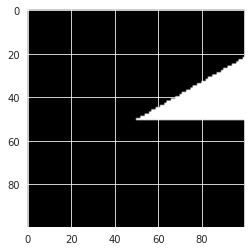

In [9]:
# TEST ORIENTAZ DEI THETA
fake_slice = draw_bool_slice(img_shape=(100, 100), theta0_deg=0, theta1_deg=30)
plt.imshow(fake_slice, cmap='gray')

# Input

In [10]:
# INPUT paths
datapath = 'TESI/SAMPLES'

# voxel size (um)
vs_um = np.array([20, 20, 20])  # um

# number of slices for fibrosis angular quantification
n_slices = 16
n_rings  = 16

# Output

In [11]:
qtz_CF_df_fname = '{}_qtz_CF_df.xlsx'  # to be filled with sample name, and saved inside sampe folder
qtz_DF_df_fname = '{}_qtz_DF_df.xlsx'  # to be filled with sample name, and saved inside sampe folder
qtz_tissue_df_fname = '{}_qtz_tissue_df.xlsx'

# 1. Collect samples and groups from folders files 

## *** TODO *** : agg il file tiff dello scattering "DIFFUSO" e lo aggiungo come layer
### creare poi anche un dict con la legenda: {0-> auto, 1->scatt, 2->mask, 3->scatt_diff}

In [12]:
# list groups
groups_names = list_subfolders_names(datapath)  # change to "sample_names"
groups_paths = list_subfolders_paths(datapath)  # change to "sample_paths"

# list ages
ages = list_subfolders_names(groups_paths[0])

print('groups: ', groups_names)
print('ages: ', ages)

# generate list and dict of samples -------------------------------------------------------
samples_list  = list()
samples_names = dict()
samples_paths = dict()

# collect samples 
for (group, groups_path) in zip(groups_names, groups_paths):    
    for age in ages:
        
        # read samples in the current directory
        samples = list_subfolders_names(os.path.join(groups_path, age))
        
        # collect in the global list
        for s in samples:
            samples_list.append(s)
        del samples
        
        # compile the dicts
        samples_names[(group, age)] = list_subfolders_names(os.path.join(groups_path, age))
        samples_paths[(group, age)] = list_subfolders_paths(os.path.join(groups_path, age))
        
print('\n----------------------')
print('Samples collected: \n')
for (g, a) in samples_names.keys():
    print('{} / {}: '.format(g,a), end='')
    print(samples_names[(g,a)])
    
    
#genero dizionari delle path ----------------------------------------------------------------
tiff_fnames, tiff_paths = dict(), dict()
#mask_fnames, mask_paths = dict(), dict()


print('\n----------------------')
print('Tiff filenames generated: \n')
# compile path dicts
for g in groups_names:
    for a in ages:
#         print('--- G: {}; A:{} --- '.format(g, a), end='')

        for (sname, spath) in zip(samples_names[(g, a)], samples_paths[(g, a)]):

            # convert 'N01' to 'N1'
            file_init = 'N' + str(int(sname.split('N')[1]))
            
            # autof + scatt
            tiff_fnames[sname] = '{}_realigned_XYZ.tif'.format(file_init)
            tiff_paths[sname]  = os.path.join(spath, tiff_fnames[sname])
            
            # myo segment
            #mask_fnames[sname] = '{}_segm_miocardium.tif'.format(file_init)
            #mask_paths[sname]  = os.path.join(spath, mask_fnames[sname])
            
            print(sname, ': ', tiff_fnames[sname])

StopIteration: 

### Generate Dataframe

In [9]:
# define columns
columns = ['Sample_id', 'Group_id', 'Group', 'Age', 'Sample']

# define dataframe
data = pd.DataFrame(data=None, 
                    index=samples_list,
                    columns=columns) 
data

,Sample_id,Group_id,Group,Age,Sample
N16,NaN,NaN,NaN,NaN,NaN
N17,NaN,NaN,NaN,NaN,NaN
N18,NaN,NaN,NaN,NaN,NaN
N19,NaN,NaN,NaN,NaN,NaN
N20,NaN,NaN,NaN,NaN,NaN
N11,NaN,NaN,NaN,NaN,NaN
N12,NaN,NaN,NaN,NaN,NaN
N14,NaN,NaN,NaN,NaN,NaN
N15,NaN,NaN,NaN,NaN,NaN
N01,NaN,NaN,NaN,NaN,NaN


In [10]:
# define columns
columns = ['Sample_id', 'Group_id', 'Group', 'Age', 'Sample Name']

# define dataframe
data = pd.DataFrame(data = None, 
                    index= samples_list,
                    columns=columns) 

# fill values
for (group_id, group) in zip(['C', 'P'], groups_names):
    for age in ages:
        for (i, s) in enumerate(samples_names[(group, age)]):
            
            data.at[s, 'Group_id']    = group_id
            data.at[s, 'Group']       = group
            data.at[s, 'Age']         = age
            data.at[s, 'Sample_id']   = s
            data.at[s, 'Sample Name'] = s  # in this case Sample Name and Sample ID are identical


# sort by Sample_id ('N01', 'N02'...)
data.sort_index(inplace=True)
data

,Sample_id,Group_id,Group,Age,Sample Name
N01,N01,P,PATHOL,13_MONTH,N01
N02,N02,P,PATHOL,13_MONTH,N02
N03,N03,P,PATHOL,13_MONTH,N03
N04,N04,P,PATHOL,13_MONTH,N04
N06,N06,P,PATHOL,7_MONTH,N06
N07,N07,P,PATHOL,7_MONTH,N07
N08,N08,P,PATHOL,7_MONTH,N08
N09,N09,P,PATHOL,7_MONTH,N09
N10,N10,P,PATHOL,7_MONTH,N10
N11,N11,C,CTRL,7_MONTH,N11


# For Loop: Perform Structural Analysis on each sample

In [11]:
# define Series of new data to collect and save
shapes_mm, MyoVols_mm3, FibrosisVols_mm3 = pd.Series(), pd.Series(), pd.Series()
Tissue_mm3, FibrosisPerc    = pd.Series(), pd.Series()

# aggiungo la nuova analisi
FibrosisDiffVols_mm3, FibrosisDiffPerc, Pool_left_ratio, Pool_left_volmm3 = pd.Series(), pd.Series(), pd.Series(), pd.Series()

spath_serie = pd.Series()

# ALL -------------------
for g in groups_names:
    for a in ages:
        for (sname, spath) in zip(samples_names[(g, a)], samples_paths[(g, a)]):                             
# ------------------------


# only the first (while devel):

# for g in [groups_names[0]]:
#     for a in [ages[0]]:
#         for (sname, spath) in zip(samples_names[(g, a)], samples_paths[(g, a)]): 
            
            print('\n\n--------------------------------------------')
            print('Elaborating: {} in {}:'.format(sname, spath))
            print('tiff file: ', tiff_fnames[sname])
            #print('mask file: ', mask_fnames[sname])
            
            # ----------------------------------------------------------------------------
            # load data and prepare layers cropped
            sample = load_tiff_in_YXZ(tiff_paths[sname])  # [row, col, z, ch]
            #mask   = load_tiff_in_YXZ(mask_paths[sname])               # [row, col, z]
            layers = compact_in_layers(sample, nlayers=4)
            print('Tiff Loaded.', end=' ')
            
            # Auto Crop of the Stack Shape based on the mask dimension
            layers_cropped = autocrop(layers, layer_to_use=0)
            print('Autocropped.', end=' ')
            
            # ---------------------------------------------------------------------------------
            # Centering the sample in the volume
            
            layers_expanded = expand_4Dvol(layers_cropped, k=4) # expand to avoid crop while shifting
            shifted         = shift_vol_to_center(layers_expanded, layer_to_use=0)  # re-center the volume
            print('Centered.', end=' ')
            
            # ------------------------------------------------------------------------------------
            # Structural analysis
            
            # TODO QUI AÌDOVRÒ SCRIVERE LE DATAFRAME
            
            # 1) hearts sides 
            shape_cropped    = layers_cropped[..., 0].shape
            shapes_mm[sname] = np.array(shape_cropped) * vs_um / 1000 # mm
            
            
            # 3) volume fibrosi compatta
            FibrosisVols_mm3[sname] = vol_in_mm3(layers_cropped[..., 1], vs_um)

            #NEW) volume fibrosi diffusa
            FibrosisDiffVols_mm3[sname] = vol_in_mm3(layers_cropped[..., 2],vs_um)
            
            # 4) Tissue volume (OR between myo mask and scatt segm -> sum vol)
            Tissue_mm3[sname] = vol_in_mm3(layers_cropped[..., 0], vs_um) 

            #NEW) ratio volume left ventricle/tissue volume
            Pool_left_volmm3[sname] = vol_in_mm3(layers_cropped[..., 3], vs_um)
            Pool_left_ratio[sname] = Pool_left_volmm3[sname] / Tissue_mm3[sname]
            
            
            # 5) percentuale fibrosi sul volume totale
            FibrosisPerc[sname] = 100 * FibrosisVols_mm3[sname] / Tissue_mm3[sname]

            #NEW) percentuale fibrosi diffusa
            FibrosisDiffPerc[sname] = 100 *  FibrosisDiffVols_mm3[sname] / Tissue_mm3[sname]

            #NEW) volume Myo
            MyoVols_mm3[sname] = Tissue_mm3[sname] - (FibrosisDiffVols_mm3[sname] + FibrosisVols_mm3[sname])
            

            #NEW) densità di fibrosi diffusa
            
            print('\nStructural Analysis performed. ', end='')
#             print('shape_mm: ', shapes_mm[sname])
#             print('M_mm3:    ', MyoVols_mm3[sname])
#             print('F_mm3:    ', FibrosisVols_mm3[sname])
#             print('F_perc:   ', FibrosisPerc[sname])
#             print('F_dens:   ', FibrosisDens[sname])
            
            # ---------------------------------------------------------------------------------
            # Angular fibrosis distribution
            fibrosis_sumZ = np.sum(shifted[..., 1], axis=-1)  # sum scattering signal over Z
            fibrosisDiff_sumZ = np.sum(shifted[..., 2], axis=-1)
            
            # return a df with [row: radii, columns: theta, values: scatt]
            qtz_CF_df = spatial_quantization(img=fibrosis_sumZ, 
                                                n_slices=n_slices, 
                                                n_rings=n_rings) 

            qtz_DF_df = spatial_quantization(img=fibrosisDiff_sumZ, 
                                                n_slices=n_slices, 
                                                n_rings=n_rings)
            
            # save qtz_CF_df of the current sample
            CF_fname = qtz_CF_df_fname.format(sname)
            qtz_CF_df.to_excel(excel_writer=os.path.join(spath, CF_fname))
            print('Angular distribution CF evaluated. Saved as: {}'.format(CF_fname))
            # save qtz_DF_df of the current sample
            DF_fname = qtz_DF_df_fname.format(sname)
            qtz_DF_df.to_excel(excel_writer=os.path.join(spath, DF_fname))
            print('Angular distribution DF evaluated. Saved as: {}'.format(DF_fname))
            # print(qtz_scatt_df)
            # append sample path to write it inside the dataframe
            spath_serie[sname] = spath
            
            #print(angular_scatt)

            #creo angular tissue distribution
            tissue_sumZ = np.sum(shifted[..., 0], axis=-1) #sommo lungo z i valori del tessuto

            #costruisco il df per radii e theta
            qtz_tissue_df =spatial_quantization(img=tissue_sumZ, n_slices=n_slices, 
                                                n_rings=n_rings)
            #salvo il file in excel
            tissue_fname = qtz_tissue_df_fname.format(sname)
            qtz_tissue_df.to_excel(excel_writer=os.path.join(spath, tissue_fname))
            print('Angular distribution Tissue evaluated. Saved as: {}'.format(tissue_fname))




--------------------------------------------
Elaborating: N16 in TESI/SAMPLES/CTRL/13_MONTH/N16:
tiff file:  N16_realigned_XYZ.tif
Tiff Loaded. Autocropped. Centered. 
Structural Analysis performed. Angular distribution CF evaluated. Saved as: N16_qtz_CF_df.xlsx
Angular distribution DF evaluated. Saved as: N16_qtz_DF_df.xlsx
Angular distribution Tissue evaluated. Saved as: N16_qtz_tissue_df.xlsx


--------------------------------------------
Elaborating: N17 in TESI/SAMPLES/CTRL/13_MONTH/N17:
tiff file:  N17_realigned_XYZ.tif
Tiff Loaded. Autocropped. Centered. 
Structural Analysis performed. Angular distribution CF evaluated. Saved as: N17_qtz_CF_df.xlsx
Angular distribution DF evaluated. Saved as: N17_qtz_DF_df.xlsx
Angular distribution Tissue evaluated. Saved as: N17_qtz_tissue_df.xlsx


--------------------------------------------
Elaborating: N18 in TESI/SAMPLES/CTRL/13_MONTH/N18:
tiff file:  N18_realigned_XYZ.tif
Tiff Loaded. Autocropped. Centered. 
Structural Analysis performe

## Insert results in the dataframe

In [12]:
# shapes_mm, MyoVols_mm3, FibrosisVols_mm3, Tissue_mm3, FibrosisPerc, FibrosisDens

data['Shape [mm]']                 = shapes_mm
data['Tissue Vol [mm3]']           = Tissue_mm3
data['Myo Vol [mm3]']              = MyoVols_mm3
data['Fibrosis Vol [mm3]']         = FibrosisVols_mm3
data['Fibrosis [%]']               = FibrosisPerc
data['Sample_Path']                = spath_serie
#aggiungere fibrosi diffusa volume, percentuale, densità e rapporto lv/tissue
data['Fibrosis Diffuse Vol [mm3]'] = FibrosisDiffVols_mm3
data['Fibrosis Diffuse [%]'] = FibrosisDiffPerc
data['Pool left Vol [mm3]'] = Pool_left_volmm3
data['Ratio LV / Tissue'] = Pool_left_ratio
data

,Sample_id,Group_id,Group,Age,Sample Name,Shape [mm],Tissue Vol [mm3],Myo Vol [mm3],Fibrosis Vol [mm3],Fibrosis [%],Sample_Path,Fibrosis Diffuse Vol [mm3],Fibrosis Diffuse [%],Pool left Vol [mm3],Ratio LV / Tissue
N01,N01,P,PATHOL,13_MONTH,N01,"[8.16, 7.0, 8.08]",187.717584,185.718488,0.409664,0.218234,TESI/SAMPLES/PATHOL/13_MONTH/N01,1.589432,0.846714,34.448304,0.183511
N02,N02,P,PATHOL,13_MONTH,N02,"[8.46, 8.12, 10.64]",228.883592,208.957904,5.875184,2.566887,TESI/SAMPLES/PATHOL/13_MONTH/N02,14.050504,6.138712,69.779464,0.304869
N03,N03,P,PATHOL,13_MONTH,N03,"[7.5, 7.08, 9.38]",179.635920,169.747480,3.517312,1.958023,TESI/SAMPLES/PATHOL/13_MONTH/N03,6.371128,3.546689,28.144032,0.156673
N04,N04,P,PATHOL,13_MONTH,N04,"[8.32, 6.74, 7.74]",155.275992,149.171736,1.877128,1.208898,TESI/SAMPLES/PATHOL/13_MONTH/N04,4.227128,2.722332,25.945336,0.167092
N06,N06,P,PATHOL,7_MONTH,N06,"[9.36, 7.86, 8.34]",243.082488,233.420608,3.113368,1.280787,TESI/SAMPLES/PATHOL/7_MONTH/N06,6.548512,2.693946,22.776960,0.093701
N07,N07,P,PATHOL,7_MONTH,N07,"[8.84, 7.28, 10.04]",226.776096,218.913520,2.084280,0.919092,TESI/SAMPLES/PATHOL/7_MONTH/N07,5.778296,2.548018,38.992112,0.171941
N08,N08,P,PATHOL,7_MONTH,N08,"[8.12, 8.38, 10.04]",222.728912,191.609352,4.561504,2.048007,TESI/SAMPLES/PATHOL/7_MONTH/N08,26.558056,11.923937,61.687576,0.276963
N09,N09,P,PATHOL,7_MONTH,N09,"[9.68, 9.34, 9.54]",253.862368,235.222840,6.330784,2.493786,TESI/SAMPLES/PATHOL/7_MONTH/N09,12.308744,4.848589,80.216024,0.315982
N10,N10,P,PATHOL,7_MONTH,N10,"[8.56, 8.9, 12.28]",286.794224,279.303480,2.547904,0.888408,TESI/SAMPLES/PATHOL/7_MONTH/N10,4.942840,1.723480,36.081736,0.125811
N11,N11,C,CTRL,7_MONTH,N11,"[7.56, 7.98, 9.24]",203.063088,197.997912,0.698968,0.344212,TESI/SAMPLES/CTRL/7_MONTH/N11,4.366208,2.150173,45.925088,0.226162


## Set numerical precisions

In [ ]:
types = {'Myo Vol [mm3]': int,
        'Fibrosis Vol [mm3]': float,
        'Tissue Vol [mm3]': int,
        'Fibrosis [%]': float,
        'Fibrosis Diffuse Vol [mm3]': int,
        'Fibrosis Diffuse [%]': float,
        'Pool left Vol [mm3]': int,
        'Ratio LV / Tissue': float
       } 

decimals = {'Shape [mm]': 1,
            'Myo Vol [mm3]': 0,
            'Fibrosis Vol [mm3]': 1,
            'Tissue Vol [mm3]': 0,
            'Fibrosis [%]': 2,
            'Fibrosis Diffuse Vol [mm3]': 0,
            'Fibrosis Diffuse [%]': 2,
            'Pool left Vol [mm3]': 0,
            'Ratio LV / Tissue': 2
           }

# format data
data_formatted = data.astype(types).round(decimals=decimals)
data_formatted

In [ ]:
# save the dataframe into an excel file
dataframe_path = os.path.join(os.path.dirname(datapath), 'TaskForce_Structural_Analysis.xlsx')

data_formatted.to_excel(excel_writer=dataframe_path)

print('Dataframe saved in:')
print(dataframe_path)